In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Preporcessing


In [3]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [3]:
df.head()


NameError: name 'df' is not defined

# Feature Engineering

In [5]:
df["Age"]=2026-df["Year_Birth"]
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reff_date=df["Dt_Customer"].max()
df["Customer_tenure"]=(reff_date-df["Dt_Customer"]).dt.days

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [7]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [8]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [9]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [10]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [11]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [12]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

# Drop Columns

In [13]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [14]:
df_cleaned.head()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2240 non-null   object 
 1   Income               2240 non-null   float64
 2   Recency              2240 non-null   int64  
 3   NumDealsPurchases    2240 non-null   int64  
 4   NumWebPurchases      2240 non-null   int64  
 5   NumCatalogPurchases  2240 non-null   int64  
 6   NumStorePurchases    2240 non-null   int64  
 7   NumWebVisitsMonth    2240 non-null   int64  
 8   Complain             2240 non-null   int64  
 9   Response             2240 non-null   int64  
 10  Age                  2240 non-null   int64  
 11  Customer_tenure      2240 non-null   int64  
 12  Total_Spending       2240 non-null   int64  
 13  Total_Children       2240 non-null   int64  
 14  Living_With          2240 non-null   object 
dtypes: float64(1), int64(12), object(2)
me

In [15]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

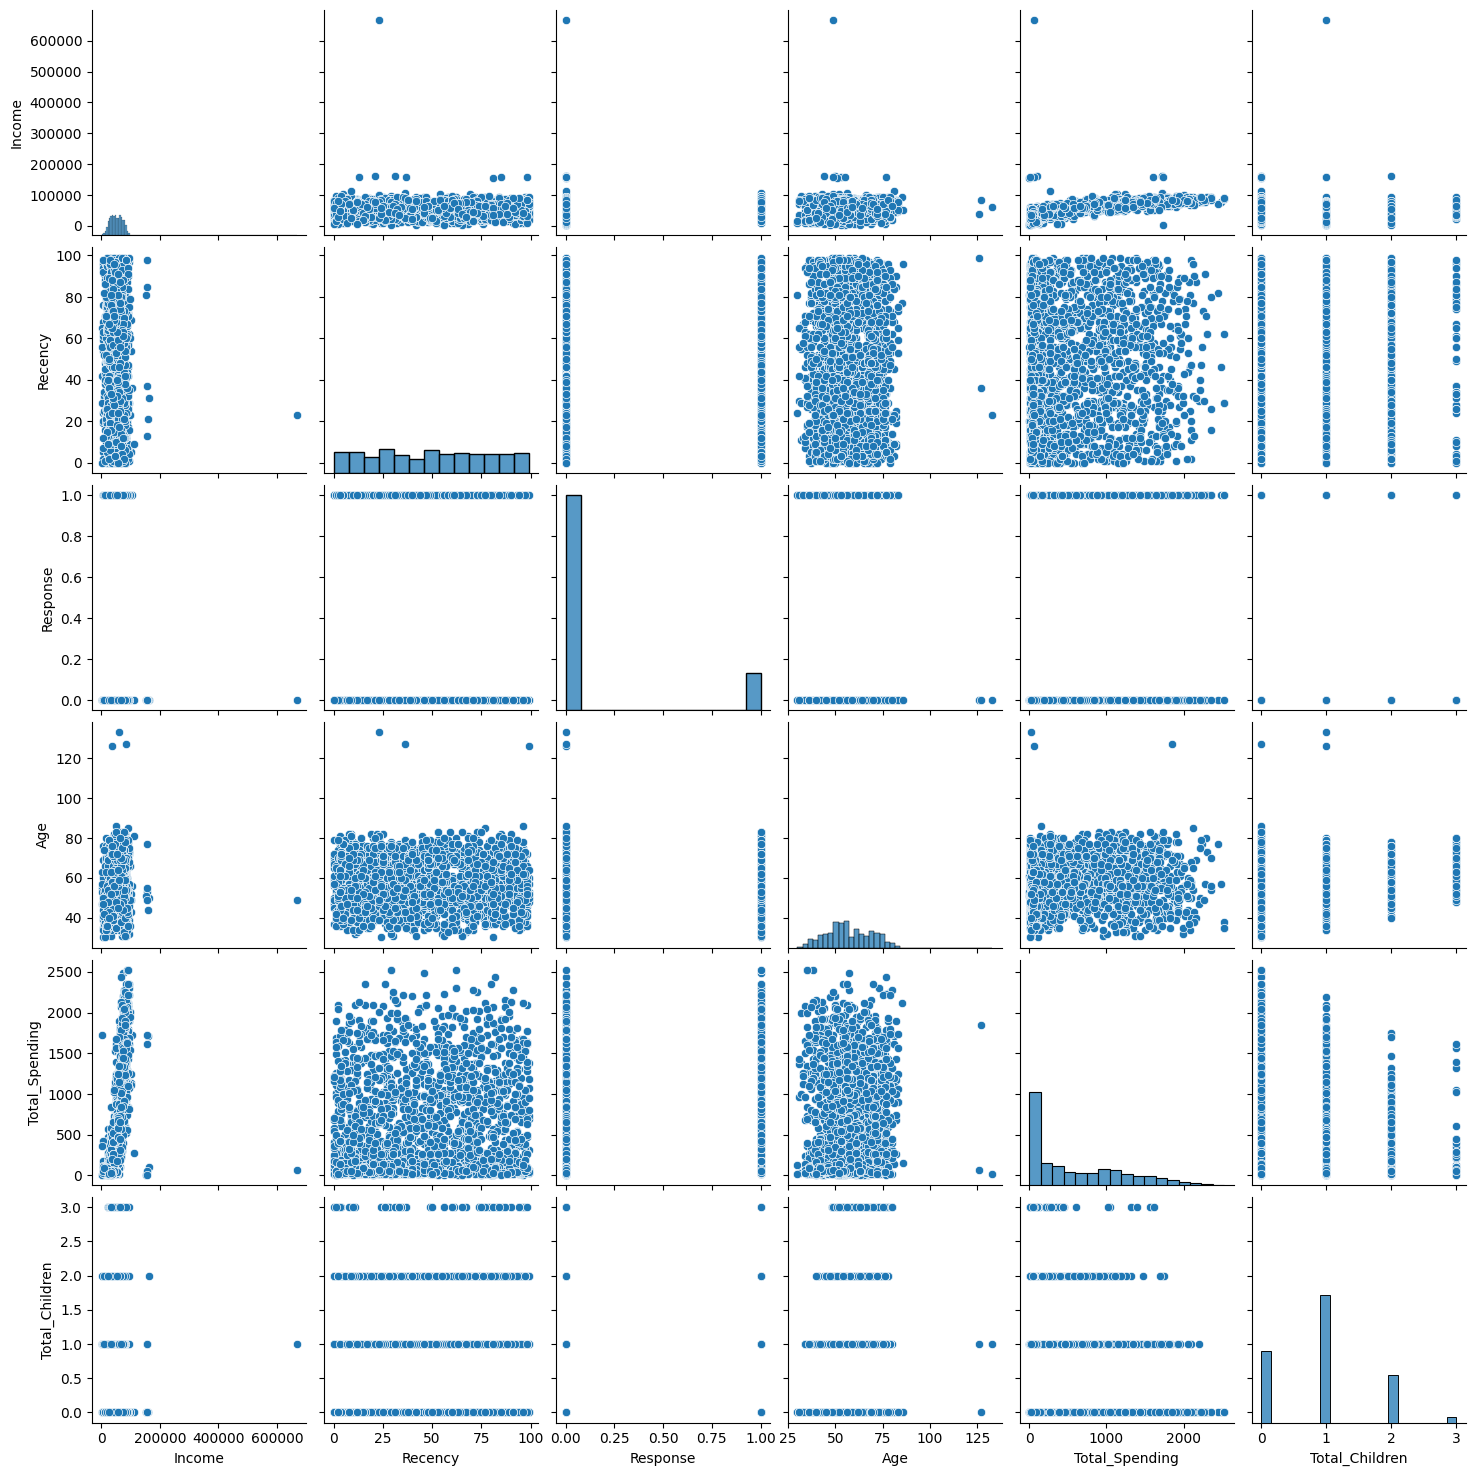

In [16]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [17]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# HeatMap

In [18]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

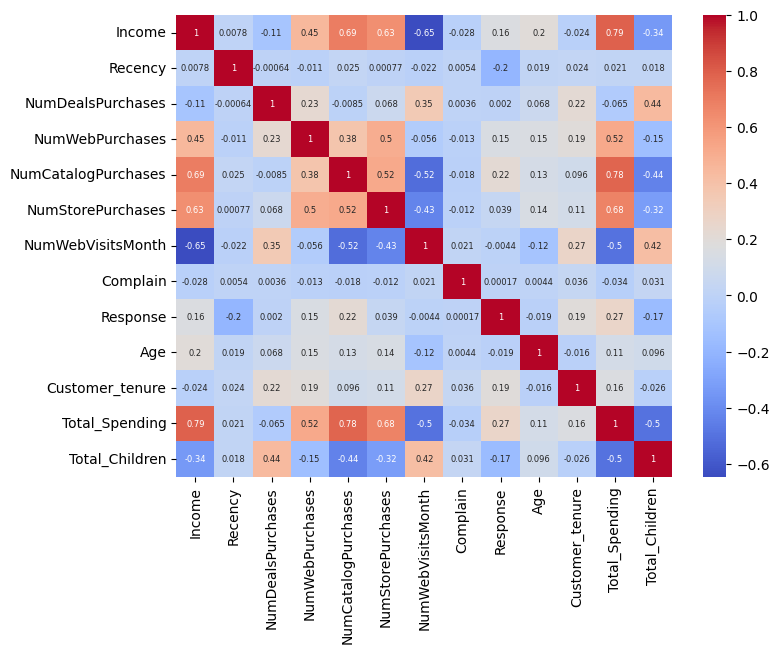

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

# Encoding

In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [22]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [23]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

# scaling


In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
X = df_encoded

In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualization

In [27]:
X_scaled.shape

(2236, 18)

In [28]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d Projection')

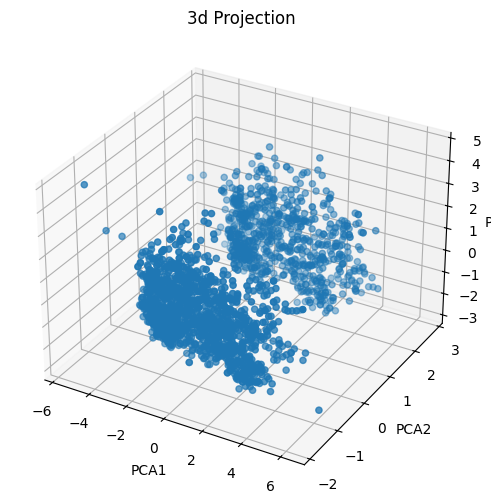

In [29]:

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

In [30]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Choose K value

### 1.Elbow

In [31]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [32]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [33]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [34]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

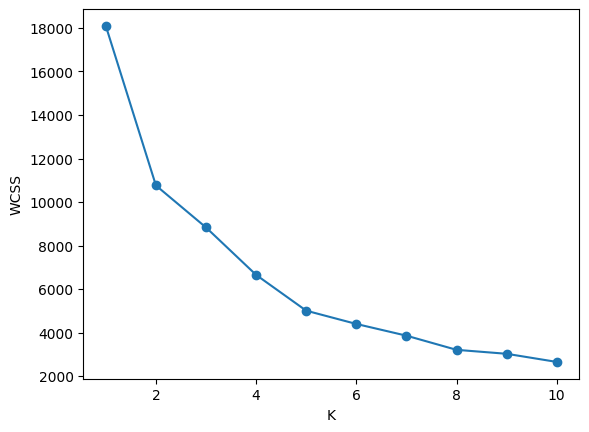

In [35]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Score

In [36]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

Text(0, 0.5, 'Silhouette score')

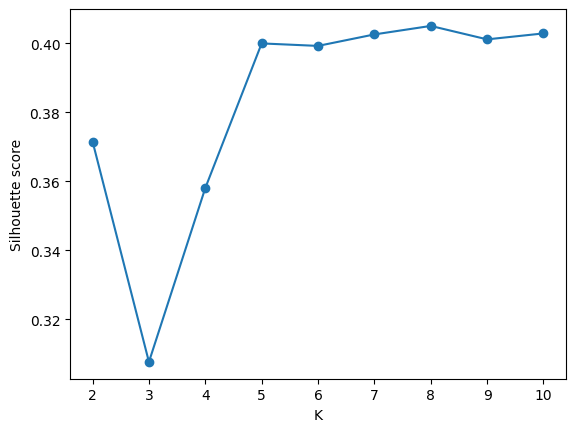

In [37]:
# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

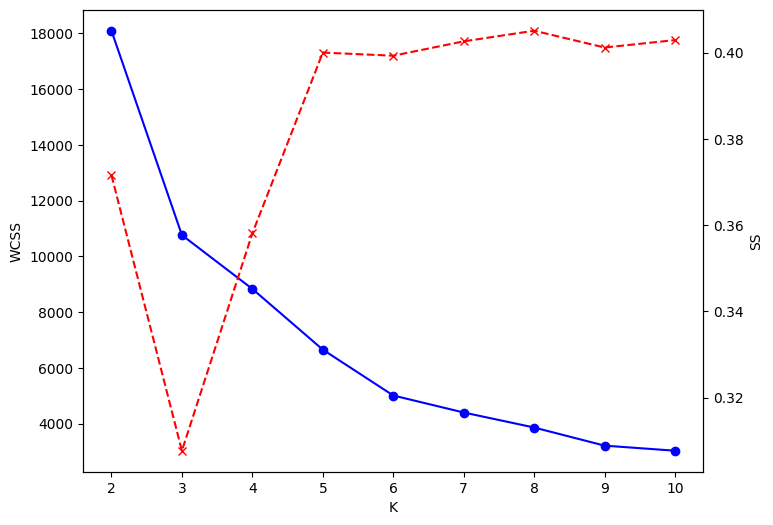

In [38]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

## K-means

In [39]:
kmeans=KMeans(n_clusters=4,random_state=42)
label=kmeans.fit_predict(X_pca)

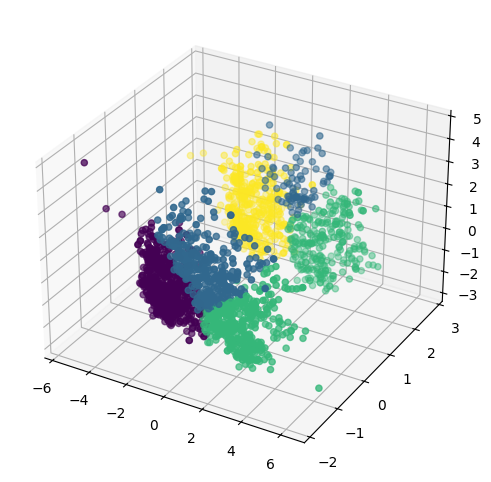

In [40]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)

## Agglomerative

In [41]:
from sklearn.cluster import AgglomerativeClustering

In [42]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
label=agg_clf.fit_predict(X_pca)

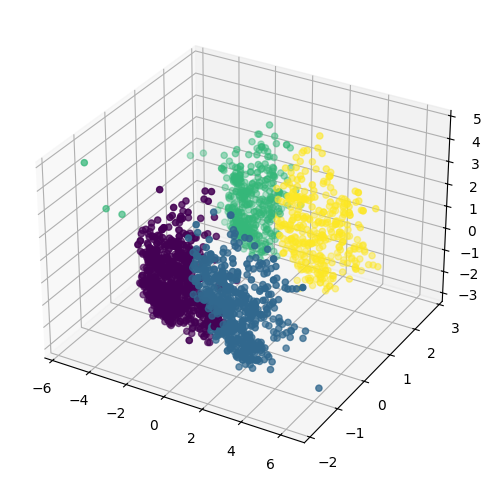

In [44]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)

# Characterization of Clustering

In [49]:

df_cleaned["Cluster"]=label

In [50]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Living_With,labels,Cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0,0


<Axes: xlabel='Cluster', ylabel='count'>

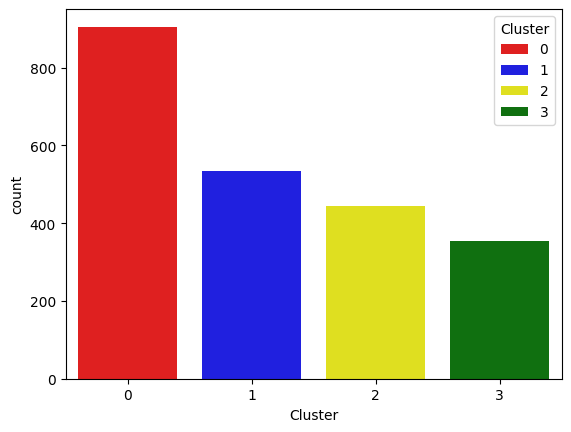

In [56]:
pal=["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["Cluster"],palette=pal,hue=df_cleaned["Cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

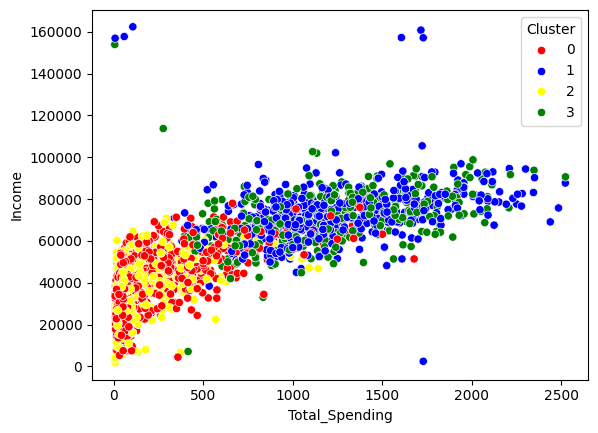

In [57]:
sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["Cluster"],palette=pal)

In [60]:
# Cluster Summary
X["Cluster"]=df_cleaned["Cluster"]
cluster_summary = X.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure  Total_Spending  Total_Children  \
Clust